<a href="https://colab.research.google.com/github/immadisunayanasri/PRODIGY_ML_03/blob/main/PRODIGY_ML_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"immadisunayanasri","key":"a41c624e8ea7f818be93a0879015567b"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle competitions download -c dogs-vs-cats

100% 812M/812M [00:35<00:00, 23.9MB/s]



In [5]:
!unzip -q dogs-vs-cats.zip
!unzip -q train.zip

In [6]:
import os
import cv2
import numpy as np
from tqdm import tqdm

In [10]:
data = []
labels = []

path = '/content/train'

for img in os.listdir(path)[:2000]:
    try:
        img_path = os.path.join(path, img)
        image = cv2.imread(img_path)
        image = cv2.resize(image, (64, 64))
        image = image.flatten()

        data.append(image)

        if 'cat' in img:
            labels.append(0)
        else:
            labels.append(1)

    except:
        pass

data = np.array(data)
labels = np.array(labels)

In [11]:
print("Data shape:", data.shape)
print("Labels:", np.unique(labels, return_counts=True))

Data shape: (2000, 12288)
Labels: (array([0, 1]), array([ 951, 1049]))


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [13]:
from sklearn.svm import SVC

model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

In [14]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.52


Dog


(np.float64(-0.5), np.float64(299.5), np.float64(279.5), np.float64(-0.5))

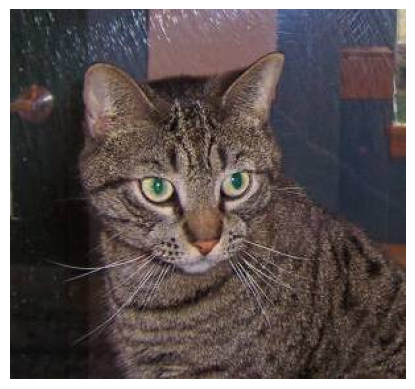

In [15]:
import matplotlib.pyplot as plt

img = cv2.imread('/content/train/cat.1.jpg')
img_resized = cv2.resize(img, (64,64)).flatten().reshape(1, -1)

prediction = model.predict(img_resized)

if prediction == 0:
    print("Cat")
else:
    print("Dog")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')